# Todesfälle nach Todesörtlichkeit, Geschlecht, 10-Jahres-Altersklasse und Herkunft
bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203

### Kurzbeschreibung
Anzahl Todesfälle von Personen der wirtschaftlichen Wohnbevölkerung der Stadt Zürich nach Bestattungsart, Geschlecht, 10-Jahres-Altersklasse, Herkunft und Jahr.

Datum: 26.08.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203


### Importiere die notwendigen Packages

In [57]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [58]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [59]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [60]:
#help(mypy_dv)
help(mypy_dl)

Help on module my_py_dataloading_functions:

NAME
    my_py_dataloading_functions

FUNCTIONS
    load_data(status, data_source, package_name, dataset_name, **kwargs)
        Diese Funktion importiert die gewünschten Daten je nach Status (Int/Prod) und Speicherort (Dropzone/Web) in Pandas ein.
        
        Parameter:
        - status (str): sind die Daten auf Integ ('int') oder auf Prod ('prod') zu beziehen? 
        - data_source (str): sind die Daten im Internet ('web'), LOSD ('ld') oder auf den Dropzones/Fileverzeichnis ('dropzone') zu beziehen?
        - package_name (str): Name des Packages. Dies entspricht dem Slug in der URL und auch dem Verzeichnisnamen auf der Dropzone. Z.B. 'bfs_bev_bildungsstand_seit1970_OD1002'
        - dataset_name (str): Name des Datensatzes (in CKAN der Ressource). z.B. "bev324od3242.csv"
        
        Optionale Parameter:
        - ckan_integ_url (str):  Pfad zur INT-Umgebung von CKAN. Default: 'https://data.integ.stadt-zuerich.ch/dataset/'
     

In [61]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [62]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [63]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [64]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [65]:
package_name = "bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203"

In [66]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV420OD4203"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203/download/BEV420OD4203.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_todesoertlichkeit_herkunft_geschlecht_ag_od4203 

data_source: web


In [67]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2013-01-01 00:00:00,2013-01-01 00:00:00
SexCd,1,1
SexKurz,M,M
SexLang,männlich,männlich
AlterV10Cd,0,0
AlterV10Lang,0- bis 9-Jährige,0- bis 9-Jährige
AlterV10Sort,1,1
HerkunftCd,1,2
HerkunftLang,Schweizer*in,Ausländer*in
HerkunftSort,1,2


Berechne weitere Attribute falls notwendig

In [68]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr              datetime64[ns]
SexCd                                 int64
SexKurz                              object
SexLang                              object
AlterV10Cd                            int64
AlterV10Lang                         object
AlterV10Sort                          int64
HerkunftCd                            int64
HerkunftLang                         object
HerkunftSort                          int64
TodOertlichkeitLevel2Cd               int64
TodOertlichkeitLevel2Lang            object
TodOertlichkeitLevel2Sort             int64
TodOertlichkeitLevel3Cd               int64
TodOertlichkeitLevel3Lang            object
TodOertlichkeitLevel3Sort             int64
AnzSterWir                            int64
StichtagDatJahr_str                  object
Jahr                         datetime64[ns]
Jahr_nbr                              int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [69]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2013 und ein Maximumjahr von 2024


### Einfache Datentests

In [70]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 3911 entries, 3910 to 0
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   StichtagDatJahr            3911 non-null   datetime64[ns]
 1   SexCd                      3911 non-null   int64         
 2   SexKurz                    3911 non-null   object        
 3   SexLang                    3911 non-null   object        
 4   AlterV10Cd                 3911 non-null   int64         
 5   AlterV10Lang               3911 non-null   object        
 6   AlterV10Sort               3911 non-null   int64         
 7   HerkunftCd                 3911 non-null   int64         
 8   HerkunftLang               3911 non-null   object        
 9   HerkunftSort               3911 non-null   int64         
 10  TodOertlichkeitLevel2Cd    3911 non-null   int64         
 11  TodOertlichkeitLevel2Lang  3911 non-null   object        
 12  TodOertlich

In [71]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 3,911 rows (observations) and 20 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [72]:
data2betested.describe()

,StichtagDatJahr,SexCd,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,TodOertlichkeitLevel2Cd,TodOertlichkeitLevel2Sort,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Sort,AnzSterWir,Jahr,Jahr_nbr
count,3911,3911,3911,3911,3911,3911,3911,3911,3911,3911,3911,3911,3911
mean,2018-05-30 05:01:10.877013504,1,64,7,1,1,768966,768966,764515,764515,10,2018-05-30 05:01:10.877013504,2018
min,2013-01-01 00:00:00,1,0,1,1,1,1100,1100,1,1,0,2013-01-01 00:00:00,2013
25%,2015-01-01 00:00:00,1,50,6,1,1,2200,2200,2,2,1,2015-01-01 00:00:00,2015
50%,2018-01-01 00:00:00,1,70,8,1,1,4200,4200,4,4,3,2018-01-01 00:00:00,2018
75%,2021-01-01 00:00:00,2,80,9,2,2,9200,9200,9,9,8,2021-01-01 00:00:00,2021
max,2024-01-01 00:00:00,2,100,11,2,2,9999999,9999999,9999999,9999999,184,2024-01-01 00:00:00,2024
std,NaN,0,23,2,0,0,2656243,2656243,2657522,2657522,21,NaN,3


Welches sind die Quartiere ohne Werte bei BEW?

In [73]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,...,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Lang,TodOertlichkeitLevel3Sort,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [74]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [75]:
data2betested.index.year.unique()

Index([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [76]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [77]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,SexCd,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,TodOertlichkeitLevel2Cd,TodOertlichkeitLevel2Sort,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Sort,AnzSterWir,Jahr_nbr
count,"3,911","3,911","3,911","3,911","3,911","3,911","3,911","3,911","3,911","3,911","3,911"
mean,1,64,7,1,1,"768,966","768,966","764,515","764,515",10,"2,018"
std,0,23,2,0,0,"2,656,243","2,656,243","2,657,522","2,657,522",21,3
min,1,0,1,1,1,"1,100","1,100",1,1,0,"2,013"
25%,1,50,6,1,1,"2,200","2,200",2,2,1,"2,015"
50%,1,70,8,1,1,"4,200","4,200",4,4,3,"2,018"
75%,2,80,9,2,2,"9,200","9,200",9,9,8,"2,021"
max,2,100,11,2,2,"9,999,999","9,999,999","9,999,999","9,999,999",184,"2,024"


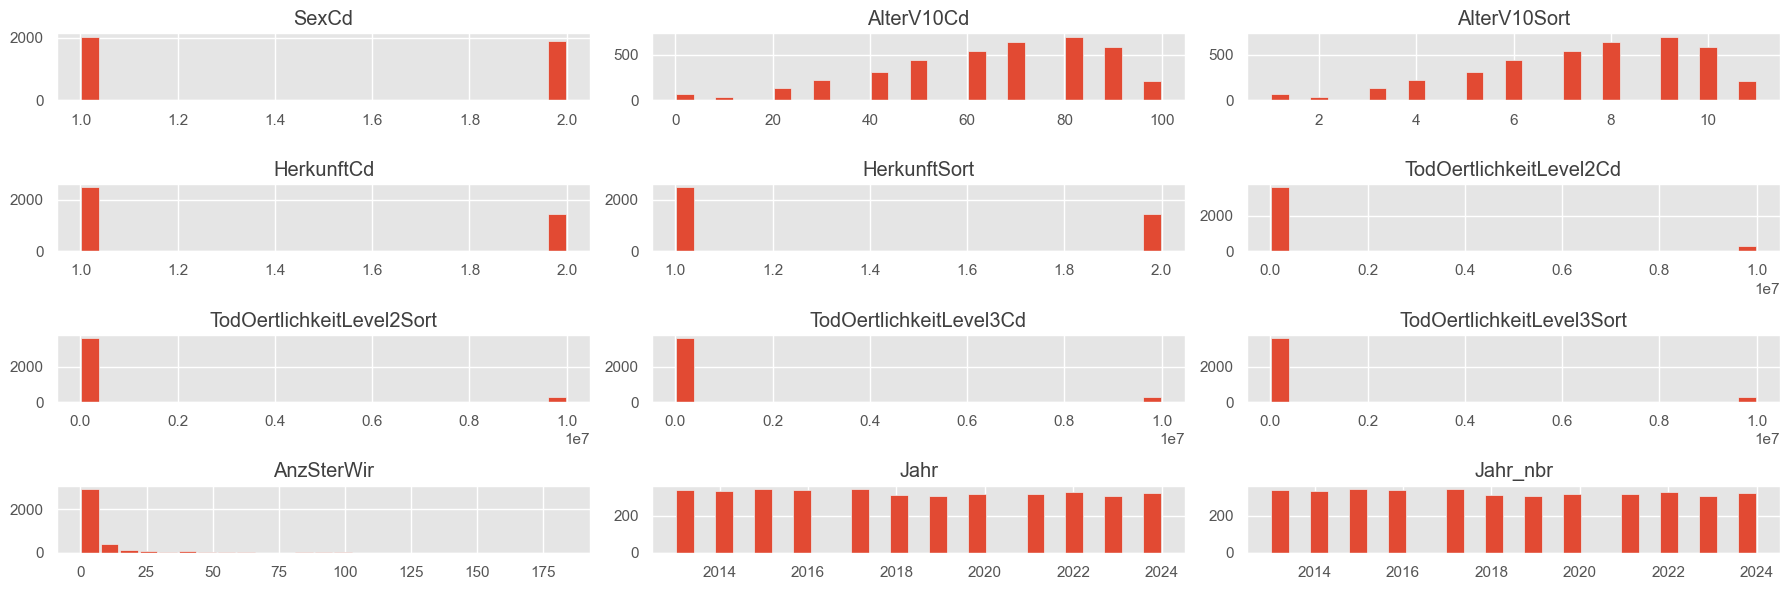

In [78]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [79]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,HerkunftCd,...,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Lang,TodOertlichkeitLevel3Sort,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [80]:
data2betested.isnull().sum()

SexCd                        0
SexKurz                      0
SexLang                      0
AlterV10Cd                   0
AlterV10Lang                 0
AlterV10Sort                 0
HerkunftCd                   0
HerkunftLang                 0
HerkunftSort                 0
TodOertlichkeitLevel2Cd      0
TodOertlichkeitLevel2Lang    0
TodOertlichkeitLevel2Sort    0
TodOertlichkeitLevel3Cd      0
TodOertlichkeitLevel3Lang    0
TodOertlichkeitLevel3Sort    0
AnzSterWir                   0
StichtagDatJahr_str          0
Jahr                         0
Jahr_nbr                     0
dtype: int64

In [81]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [82]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzSterWir
0,2024-01-01,2024,3063
1,2023-01-01,2023,3106
2,2022-01-01,2022,3350


In [83]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzSterWir
0,2,Ausländer*in,5029
1,1,Schweizer*in,34212


In [84]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV10Cd', 'AlterV10Lang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('AlterV10Cd', ascending=True) 
agg_age.reset_index().head(11)

,AlterV10Cd,AlterV10Lang,sum_AnzSterWir
0,0,0- bis 9-Jährige,95
1,10,10- bis 19-Jährige,46
2,20,20- bis 29-Jährige,211
3,30,30- bis 39-Jährige,410
4,40,40- bis 49-Jährige,834
5,50,50- bis 59-Jährige,1924
6,60,60- bis 69-Jährige,3532
7,70,70- bis 79-Jährige,6911
8,80,80- bis 89-Jährige,13825
9,90,90- bis 99-Jährige,10832


In [85]:
agg_bestg = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['TodOertlichkeitLevel2Cd','TodOertlichkeitLevel2Lang', 'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd','TodOertlichkeitLevel3Lang', 'TodOertlichkeitLevel3Sort']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodOertlichkeitLevel2Sort', ascending=True) 
agg_bestg.reset_index().head(30)

,TodOertlichkeitLevel2Cd,TodOertlichkeitLevel2Lang,TodOertlichkeitLevel2Sort,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Lang,TodOertlichkeitLevel3Sort,sum_AnzSterWir
0,1100,Spital in Zürich (städtisch),1100,1,Spitäler in Zürich,1,5727
1,1200,Spital in Zürich (übrige),1200,1,Spitäler in Zürich,1,4430
2,2100,Pflegezentrum in Zürich (städtisch),2100,2,Pflegezentren in Zürich,2,6830
3,2200,Pflegezentrum in Zürich (übrige),2200,2,Pflegezentren in Zürich,2,1683
4,3100,Alterszentrum in Zürich (städtisch),3100,3,Alterszentren in Zürich,3,2638
5,3200,Alterszentrum in Zürich (übrige),3200,3,Alterszentren in Zürich,3,4509
6,4100,Privat in Zürich (städtische Alterswohnung SAW),4100,4,Privat in Zürich,4,233
7,4200,Privat in Zürich (übrige),4200,4,Privat in Zürich,4,8451
8,5100,Im Freien in Zürich,5100,5,Übrige Örtlichkeiten in Zürich,5,40
9,5200,Zürich Übrige,5200,5,Übrige Örtlichkeiten in Zürich,5,149


In [86]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang',
       'AlterV10Sort', 'HerkunftCd', 'HerkunftLang', 'HerkunftSort', 'TodOertlichkeitLevel2Cd',
       'TodOertlichkeitLevel2Lang', 'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd',
       'TodOertlichkeitLevel3Lang', 'TodOertlichkeitLevel3Sort', 'AnzSterWir',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [87]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,HerkunftCd,...,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Lang,TodOertlichkeitLevel3Sort,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,
2024-01-01,1,M,männlich,0,0- bis 9-Jährige,1,2,...,4,Privat in Zürich,4,1,2024-01-01,2024-01-01,2024
2024-01-01,1,M,männlich,10,10- bis 19-Jährige,2,1,...,1,Spitäler in Zürich,1,0,2024-01-01,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [88]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterV10Cd', 'AlterV10Lang',]) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,AlterV10Cd,AlterV10Lang,sum_AnzSterWir
0,2013-01-01,0,0- bis 9-Jährige,5
1,2013-01-01,10,10- bis 19-Jährige,11
2,2013-01-01,20,20- bis 29-Jährige,13


In [89]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('AlterV10Cd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "AlterV10Lang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Todesfälle nach Altersgruppe, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Herkunft

In [90]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'HerkunftLang', 'HerkunftCd']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,HerkunftLang,HerkunftCd,sum_WBev
0,2013-01-01,Ausländer*in,2,377
1,2013-01-01,Schweizer*in,1,3088
2,2014-01-01,Ausländer*in,2,388


In [91]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Todesfälle nach Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [92]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang',
       'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd', 'TodOertlichkeitLevel3Lang',
       'TodOertlichkeitLevel3Sort', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [93]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang','TodOertlichkeitLevel2Sort']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg3.reset_index().head(3)

,StichtagDatJahr,TodOertlichkeitLevel2Cd,TodOertlichkeitLevel2Lang,TodOertlichkeitLevel2Sort,sum_WBev
0,2013-01-01,1100,Spital in Zürich (städtisch),1100,552
1,2013-01-01,9999999,Unbekannt,9999999,228
2,2013-01-01,10100,Ausland,10100,40


In [94]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index().sort_values('TodOertlichkeitLevel2Sort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "TodOertlichkeitLevel2Lang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Todesfälle nach Todesörtlichkeit, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [95]:
#.groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang', 'HerkunftLang', 'HerkunftCd']) \
myAggBar = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang','TodOertlichkeitLevel3Cd', 'TodOertlichkeitLevel3Lang','TodOertlichkeitLevel3Sort']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values(['AlterV10Cd'], ascending=[True]) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,AlterV10Cd,AlterV10Lang,TodOertlichkeitLevel3Cd,TodOertlichkeitLevel3Lang,TodOertlichkeitLevel3Sort,sum_WBev
0,2024-01-01,0,0- bis 9-Jährige,1,Spitäler in Zürich,1,2
1,2024-01-01,0,0- bis 9-Jährige,4,Privat in Zürich,4,2
2,2024-01-01,0,0- bis 9-Jährige,9999999,Unbekannt,9999999,1


In [96]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

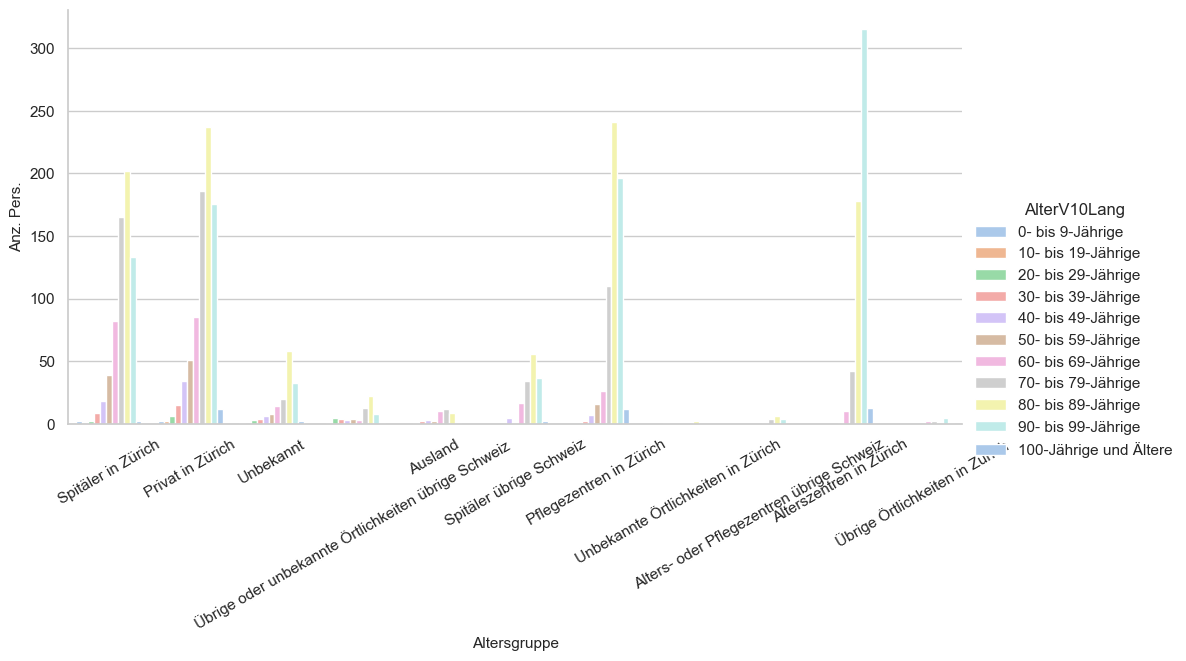

In [97]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="TodOertlichkeitLevel3Lang"
            , y="sum_WBev"
            , hue="AlterV10Lang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [98]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang',
       'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd', 'TodOertlichkeitLevel3Lang',
       'TodOertlichkeitLevel3Sort', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [113]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang','TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('AlterV10Cd', ascending=True) 
myFG.reset_index()

,StichtagDatJahr,AlterV10Cd,AlterV10Lang,TodOertlichkeitLevel2Cd,TodOertlichkeitLevel2Lang,sum_WBev
0,2013-01-01,0,0- bis 9-Jährige,1200,Spital in Zürich (übrige),2
1,2017-01-01,0,0- bis 9-Jährige,1200,Spital in Zürich (übrige),5
2,2023-01-01,0,0- bis 9-Jährige,4200,Privat in Zürich (übrige),4
3,2023-01-01,0,0- bis 9-Jährige,9300,Schweiz Übrige und unbekannt (ohne Kanton Zürich),1
4,2023-01-01,0,0- bis 9-Jährige,10100,Ausland,1
...,...,...,...,...,...,...
1544,2015-01-01,100,100-Jährige und Ältere,9300,Schweiz Übrige und unbekannt (ohne Kanton Zürich),0
1545,2015-01-01,100,100-Jährige und Ältere,9200,Kanton Zürich Übrige und unbekannt (ohne Stadt...,0
1546,2015-01-01,100,100-Jährige und Ältere,8200,Alters- oder Pflegezentrum ausserhalb vom Kant...,0
1547,2014-01-01,100,100-Jährige und Ältere,1100,Spital in Zürich (städtisch),5


In [100]:
myFG.reset_index().columns

Index(['StichtagDatJahr', 'AlterV10Cd', 'AlterV10Lang', 'TodOertlichkeitLevel2Cd',
       'TodOertlichkeitLevel2Lang', 'sum_WBev'],
      dtype='object')

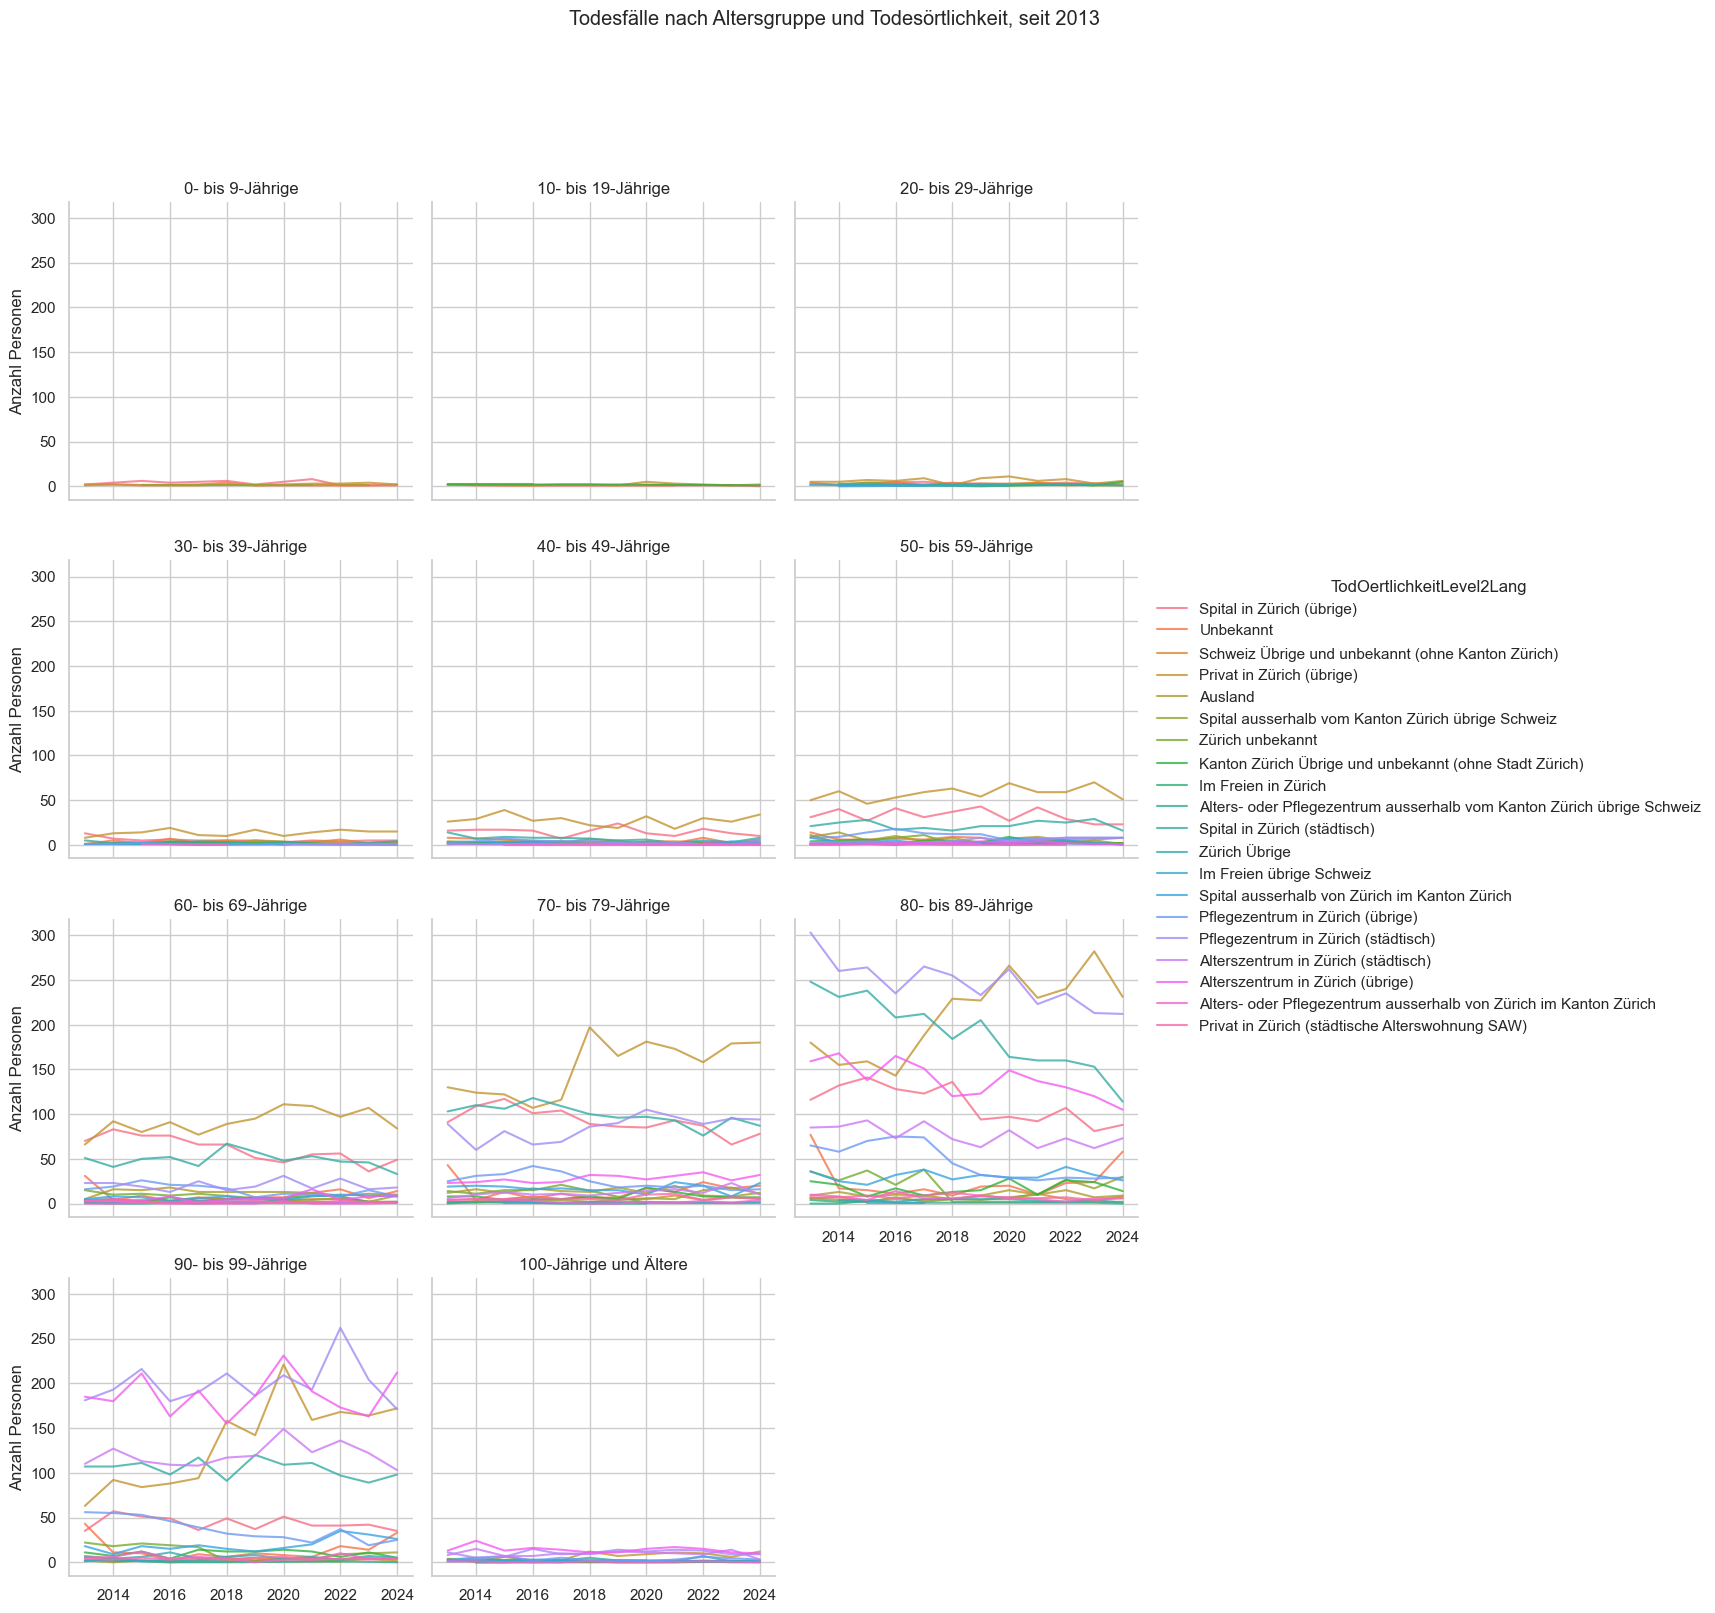

In [101]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('AlterV10Cd', ascending=True)
    ,col = "AlterV10Lang"
    ,hue = "TodOertlichkeitLevel2Lang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Todesfälle nach Altersgruppe und Todesörtlichkeit, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

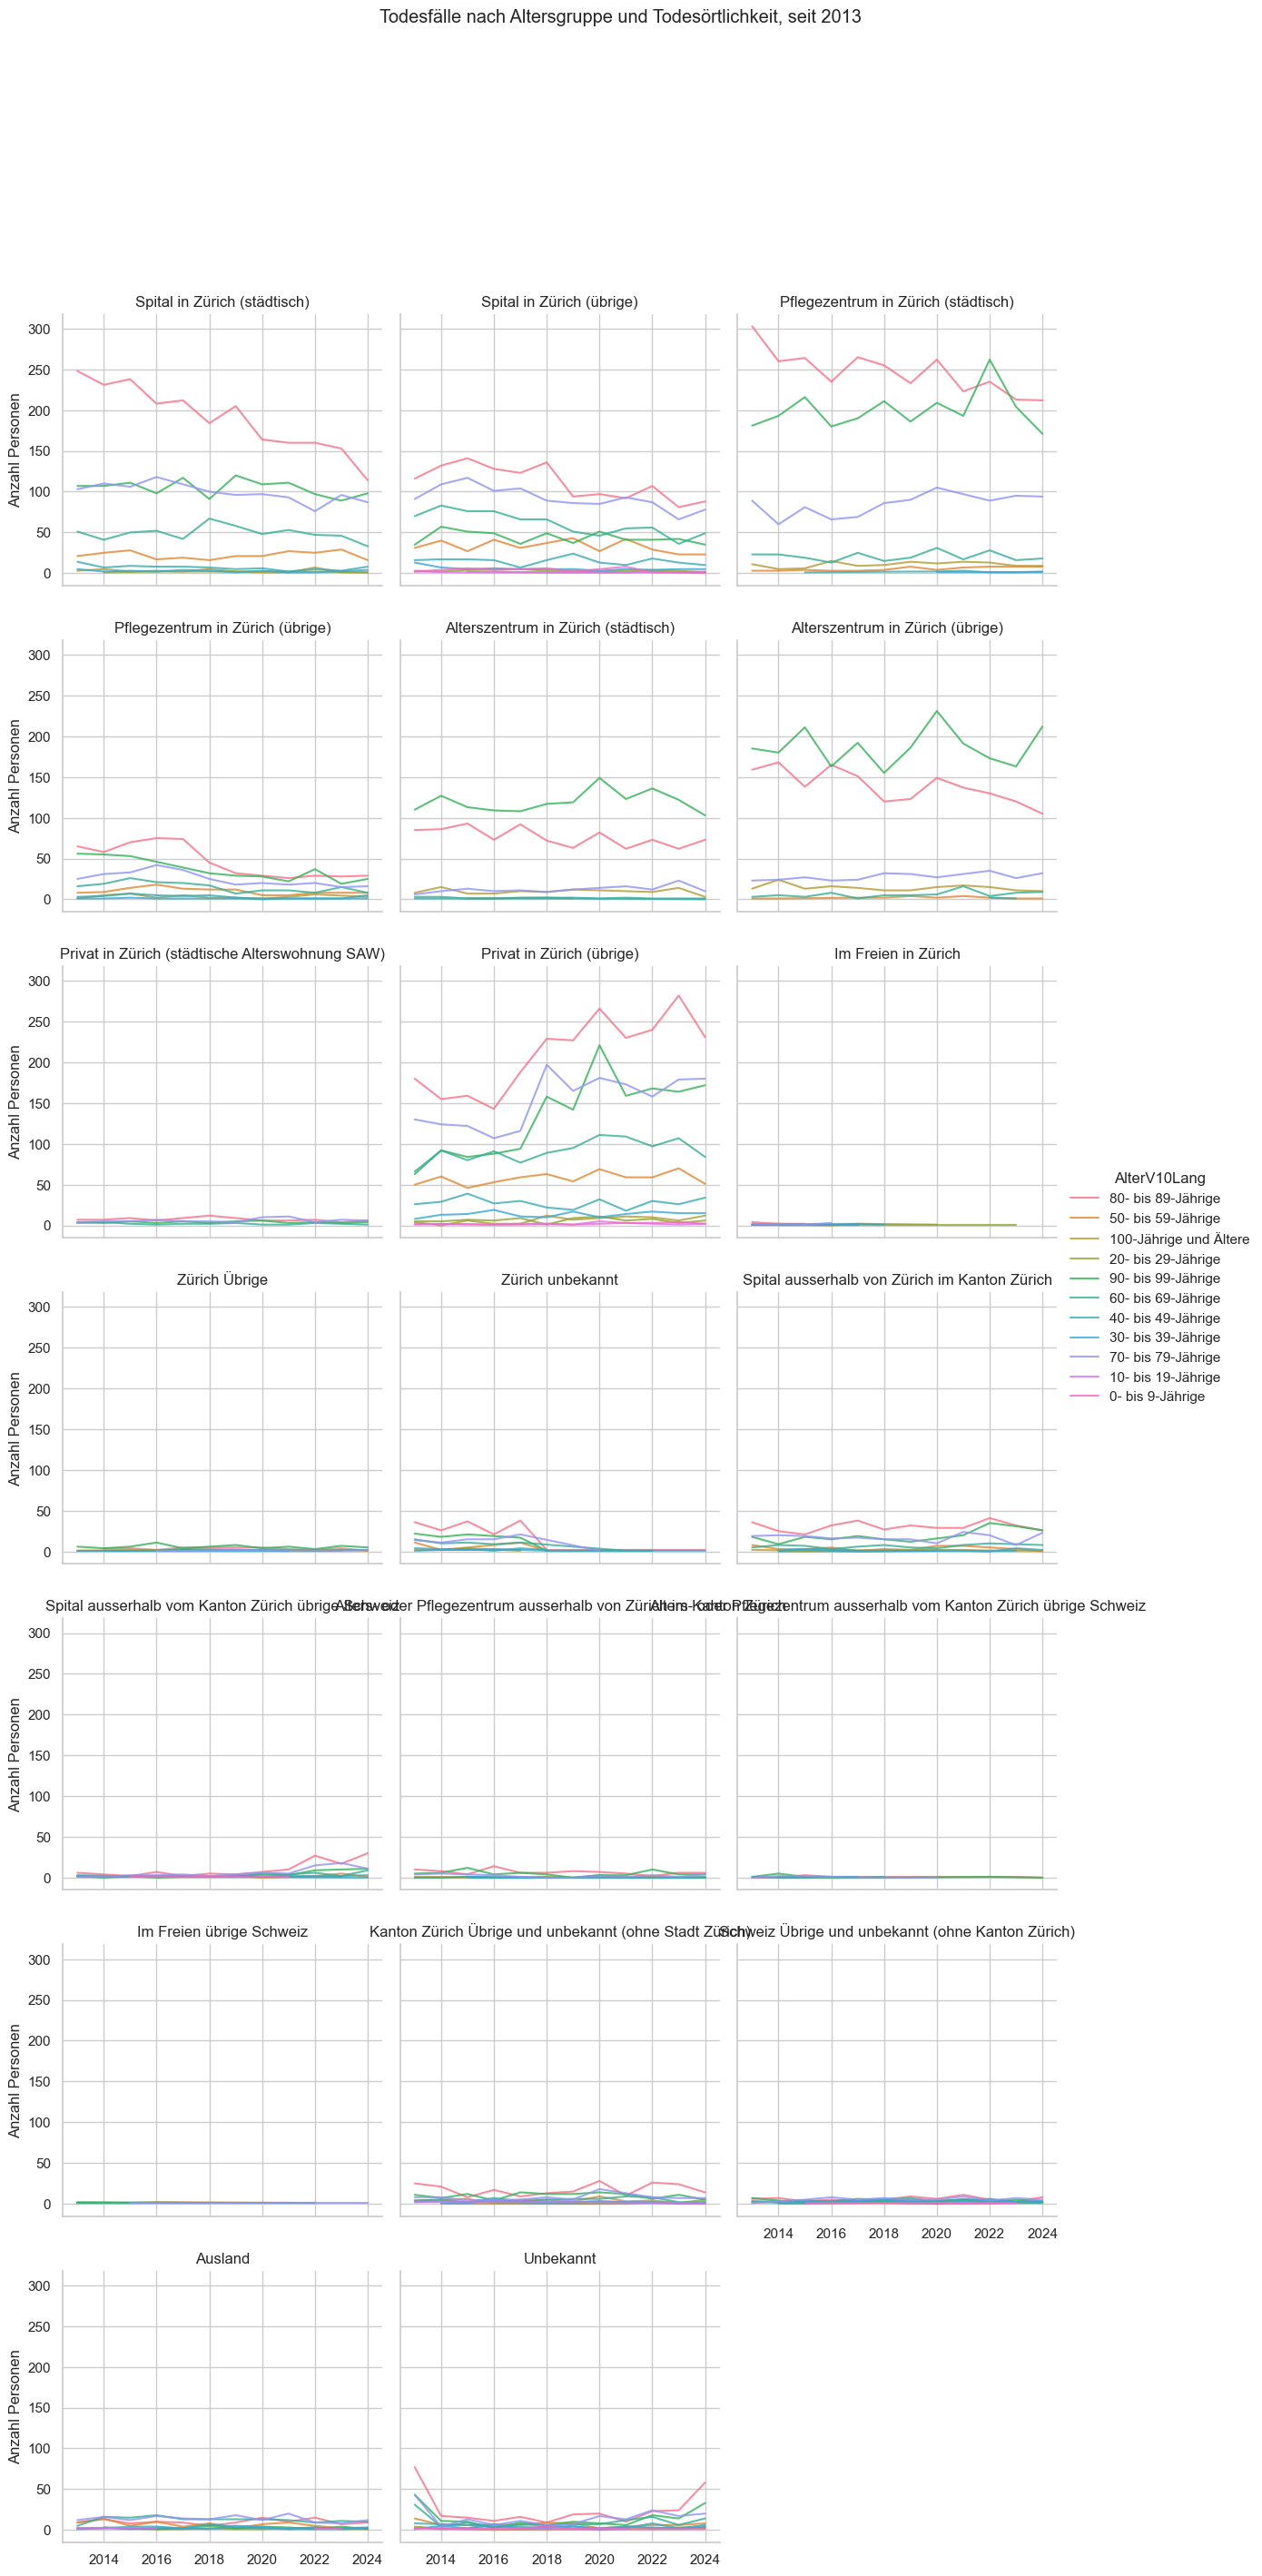

In [102]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('TodOertlichkeitLevel2Cd', ascending=True)
    ,col = "TodOertlichkeitLevel2Lang"
    ,hue = "AlterV10Lang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Todesfälle nach Altersgruppe und Todesörtlichkeit, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [103]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [104]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang',
       'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd', 'TodOertlichkeitLevel3Lang',
       'TodOertlichkeitLevel3Sort', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [115]:
# Extrahiere die Top-Fahrzeugmarken
attr2becolored = data2betested['TodOertlichkeitLevel2Lang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Spital in Zürich (übrige)': '#0017BF', 'Privat in Zürich (übrige)': '#0072D7', 'Spital in Zürich (städtisch)': '#00A5D2', 'Kanton Zürich Übrige und unbekannt (ohne Stadt Zürich)': '#5E359A', 'Zürich unbekannt': '#BA0062', 'Unbekannt': '#DA5563', 'Pflegezentrum in Zürich (städtisch)': '#00615D', 'Alterszentrum in Zürich (städtisch)': '#00770F', 'Alterszentrum in Zürich (übrige)': '#7BA600', 'Alters- oder Pflegezentrum ausserhalb von Zürich im Kanton Zürich': '#7B4100', 'Im Freien übrige Schweiz': '#DC5500', 'Zürich Übrige': '#DA9C00', 'Alters- oder Pflegezentrum ausserhalb vom Kanton Zürich übrige Schweiz': '#5D4BFE', 'Pflegezentrum in Zürich (übrige)': '#4AA9FF', 'Im Freien in Zürich': '#55FFFF', 'Spital ausserhalb vom Kanton Zürich übrige Schweiz': '#986AD5', 'Schweiz Übrige und unbekannt (ohne Kanton Zürich)': '#FC4C99', 'Ausland': '#FF919A', 'Spital ausserhalb von Zürich im Kanton Zürich': '#349894', 'Privat in Zürich (städtische Alterswohnung SAW)': '#44B14A'}

##### Todesfälle nach Altersgruppe, Herkunft, Geschlecht und Todesörtlichkeit

In [116]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'TodOertlichkeitLevel2Cd', 'TodOertlichkeitLevel2Lang',
       'TodOertlichkeitLevel2Sort', 'TodOertlichkeitLevel3Cd', 'TodOertlichkeitLevel3Lang',
       'TodOertlichkeitLevel3Sort', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [117]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['AlterV10Lang','SexLang', 'TodOertlichkeitLevel2Lang']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000002014C693550>, 'AlterV10Lang', 'SexLang', 'TodOertlichkeitLevel2Lang']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet

In [118]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['AlterV10Lang','SexLang', 'TodOertlichkeitLevel2Lang']
    ,values="AnzSterWir"
    ,color="TodOertlichkeitLevel2Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000002014C693550>, 'AlterV10Lang', 'SexLang', 'TodOertlichkeitLevel2Lang']
Typ von path: <class 'list'>


In [119]:
treeMap3 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['TodOertlichkeitLevel2Lang','AlterV10Lang','SexLang', ]
    ,values="AnzSterWir"
    ,color="TodOertlichkeitLevel2Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x000002014D7EB550>, 'TodOertlichkeitLevel2Lang', 'AlterV10Lang', 'SexLang']
Typ von path: <class 'list'>


#### Todesörtlichkeit Level 3

In [120]:
# Extrahiere die Top-Fahrzeugmarken
attr2becolored = data2betested['TodOertlichkeitLevel3Lang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Spitäler in Zürich': '#A30059', 'Privat in Zürich': '#DB247D', 'Übrige oder unbekannte Örtlichkeiten übrige Schweiz': '#FF579E', 'Unbekannte Örtlichkeiten in Zürich': '#FFA8D0', 'Unbekannt': '#E4E0DF', 'Pflegezentren in Zürich': '#A8DBB1', 'Alterszentren in Zürich': '#55BC5D', 'Alters- oder Pflegezentren übrige Schweiz': '#1F9E31', 'Übrige Örtlichkeiten in Zürich': '#10652A', 'Spitäler übrige Schweiz': '#0017BF', 'Ausland': '#0072D7'}


In [121]:
treeMap4 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['TodOertlichkeitLevel3Lang','AlterV10Lang','SexLang', ]
    ,values="AnzSterWir"
    ,color="TodOertlichkeitLevel3Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap4

path: [<plotly.express._special_inputs.Constant object at 0x0000020147172690>, 'TodOertlichkeitLevel3Lang', 'AlterV10Lang', 'SexLang']
Typ von path: <class 'list'>


In [122]:
treeMap5 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_max_date].reset_index().query("AnzSterWir>0")
    ,levels=['TodOertlichkeitLevel3Lang','AlterV10Lang','SexLang', ]
    ,values="AnzSterWir"
    ,color="TodOertlichkeitLevel3Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit,  "+data_max_date
)
treeMap5

path: [<plotly.express._special_inputs.Constant object at 0x00000201477383D0>, 'TodOertlichkeitLevel3Lang', 'AlterV10Lang', 'SexLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1433&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3DPageView%253DPersonal%2DShowWebPart%253D%257B6087A3E7%2D%2D8AC8%2D%2D40BA%2D%2D8278%2D%2DDECFACE124FF%257D%2DSortField%253DCreated%2DSortDir%253DAsc&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------